In [104]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Data
from dataloader import samlet_df
from dataloader import(skjorte_data, bukse_data, tshirt_data, langærmet_data, jakke_data, 
    fleece_data, overall_data, forklæde_data, busseron_data, kokkejakke_data, shorts_data, kittel_data)
pca_df = samlet_df.copy()

## PCA funktion

In [117]:
# Fit PCA og plot
def plot_pca(df, title, top_n=25):
    df = df.copy()
    
    # Fremhæv top-N kategorier, resten som "Anden"
    top_cats = df[df["Kategori"] != "Andet"]["Kategori"].value_counts().nlargest(top_n).index
    df["Kategori_plot"] = df["Kategori"].apply(
        lambda x: x if x in top_cats else "Andet"
    )
    
    ## PCA
    # Features
    features = ["Dage i cirkulation", "Total antal vask"]
    X = df[features]

    # Standardiser data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df["PC1"] = X_pca[:, 0]
    df["PC2"] = X_pca[:, 1]

    # Forklaret varians
    explained = pca.explained_variance_ratio_
    print("Forklaret varians pr. komponent:", explained)


    ## Plot
    fig, ax = plt.subplots(figsize=(9, 6))

    # Plot "Anden" først så den ligger bagest
    mask_other = df["Kategori_plot"] == "Anden"
    ax.scatter(df.loc[mask_other, "PC1"], df.loc[mask_other, "PC2"],
            label="Anden", alpha=0.15, s=20, color="lightgray")

    # Kategorier og farver
    categories = df["Kategori"].unique()
    colors_combined = (
    [plt.cm.tab20(i) for i in range(20)] +
    [plt.cm.tab20b(i) for i in range(20)])
    cmap_custom = colors_combined[:len(categories)]

    # Plot hver kategori med sin farve
    for i, cat in enumerate(categories):
        mask = df["Kategori_plot"] == cat
        ax.scatter(df.loc[mask, "PC1"], df.loc[mask, "PC2"],
                   label=cat, alpha=0.7, s=30, color=cmap_custom[i])

    var1 = explained[0] * 100
    var2 = explained[1] * 100
    ax.set_xlabel(f"Principal Component 1 ({var1:.2f}%)")
    ax.set_ylabel(f"Principal Component 2 ({var2:.2f}%)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Legend udenfor plot (hvis der er flere kategorier)
    if len(categories) > 1:
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.show()

    return pca

## Plots

### Samlet plot

Forklaret varians pr. komponent: [0.75126951 0.24873049]


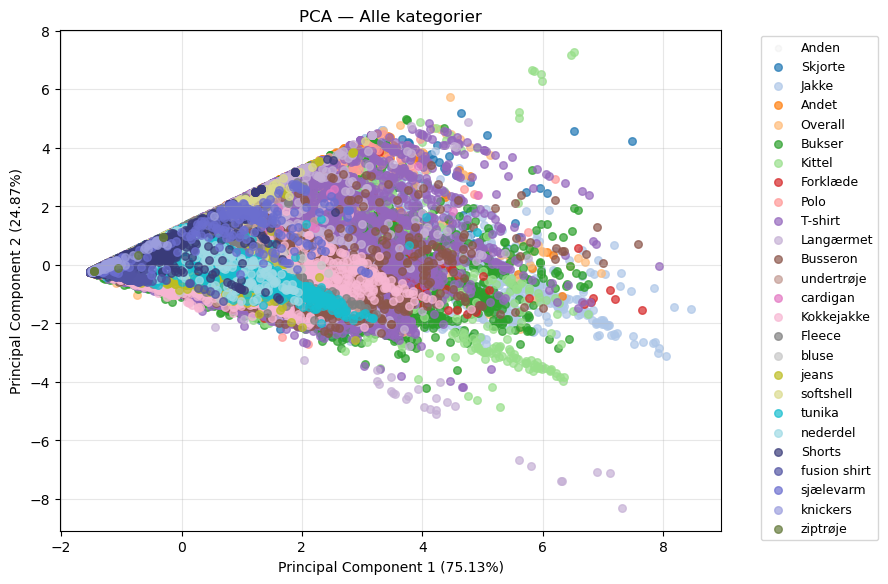

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [118]:
plot_pca(pca_df, "PCA — Alle kategorier")

Forklaret varians pr. komponent: [0.75551387 0.24448613]


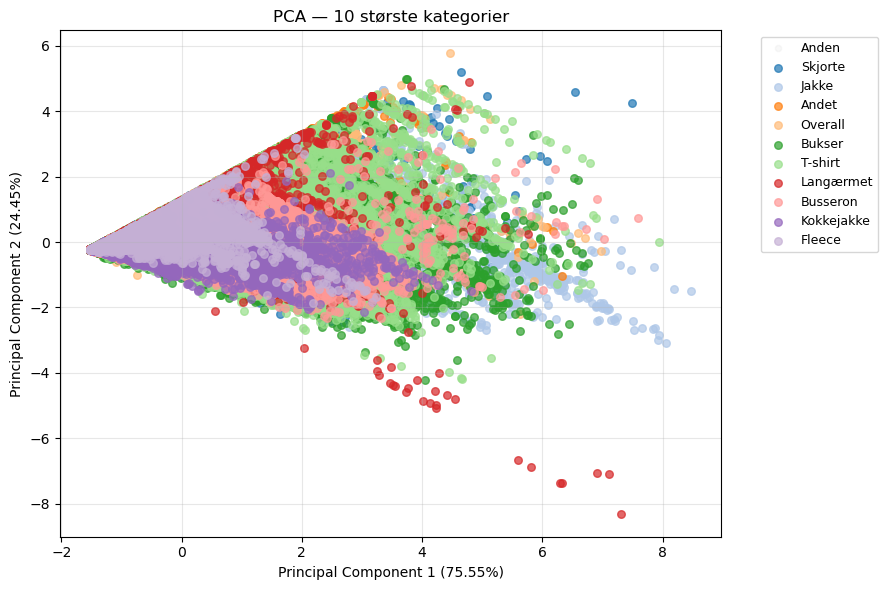

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [122]:
største_kategorier = pca_df["Kategori"].value_counts().nlargest(10).index
største_kategorier_df = pca_df[pca_df["Kategori"].isin(største_kategorier)]
plot_pca(største_kategorier_df, "PCA — 10 største kategorier")